# 220119 F2 run11: Behavior Decoding

Stage 3 for the restarted V2a workflow. This notebook first consumes the saved outputs from `cluster_clean_reconstruct.ipynb`: per-method cleaned traces and cluster-selection JSON files under `outputs/linear/v2a-RSNs/<data_name>/<method>/`. It then runs the two downstream behavior analyses on those chained artifacts:

1. supervised behavior decoding for tail vigor and bout state;
2. causal-state behavior decoding on the same raw and cleaned trace variants.

These chained analyses write descriptive downstream outputs to `outputs/behavior_decoding/v2a-RSNs/<data_name>/`. The final section optionally runs the strict fold-local evaluator into `outputs/evaluation/v2a-RSNs/<data_name>/`; that strict section intentionally refits preprocessing inside folds and is the leakage-safe path for primary manuscript claims.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists() and (path / "src").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False})
print(f"Project root: {PROJECT_ROOT}")


import json

from ica_denoising.behavior_decoding import (
    TraceVariant,
    load_trace_variants,
    make_behavior_targets,
    plot_behavior_preservation_summary,
    plot_behavior_trace_evidence,
    run_decoding_experiment,
    summarize_trace_preservation,
)
from ica_denoising.bss_notebook import (
    BSS_METHODS,
    available_datasets,
    cleaned_trace_output_paths,
    cluster_selection_output_path,
    get_dataset,
    load_traces,
    output_directory,
)
from ica_denoising.causal_behavior_decoding import CausalStateConfig, fit_causal_state_model
from ica_denoising.evaluation_diagnostics import build_provenance_manifest
from ica_denoising.evaluation_runner import load_evaluation_config, run_dataset_evaluation


Project root: /Users/sadiqadedayo/Documents/projects/ICA/ica-denoising


## Configuration

`RUN_CHAINED_BEHAVIOR_DECODING` runs the stage-dependent analysis that loads outputs from `cluster_clean_reconstruct.ipynb`. `RUN_STRICT_EVALUATION` runs the fold-local evaluator after that; it is independent by design.

In [2]:
DATASET_KEY = "v2a-RSNs/220119_F2_run11_fluorescence"
METHODS_TO_RUN = list(BSS_METHODS)

RUN_CHAINED_BEHAVIOR_DECODING = True
RUN_STRICT_EVALUATION = True
STRICT_CONFIG_NAME = "evaluation.example.json"  # use evaluation.smoke.json for quick checks

BOUT_QUANTILE = 0.75
SMOOTH_WINDOW = 3
DECODER_LAGS = (0, 1, 2)
TARGET_SHIFT = 0
BEHAVIOR_N_SPLITS = 5
BEHAVIOR_GAP = 3
RIDGE_ALPHA = 10.0
NULL_BLOCK_SIZE = 60
RANDOM_STATE = 0
N_JOBS = 1

CAUSAL_WINDOW = 15
CAUSAL_TARGET_SHIFTS = (0,)
CAUSAL_LATENT_DIM = 3
CAUSAL_N_SPLITS = 5
CAUSAL_GAP = 14  # must be at least CAUSAL_WINDOW - 1
CAUSAL_RIDGE_ALPHA = 5.0

PLOT_DPI = 300

dataset, traces = load_traces(DATASET_KEY, PROJECT_ROOT)
OUTPUT_DATA_NAME = dataset.recording_id or dataset.data_name
CHAINED_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "behavior_decoding" / dataset.group / OUTPUT_DATA_NAME
CHAINED_FIGURE_DIR = CHAINED_OUTPUT_DIR / "figures"
STRICT_OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "evaluation"
STRICT_OUTPUT_DIR = STRICT_OUTPUT_ROOT / dataset.group / OUTPUT_DATA_NAME

print(f"Dataset: {dataset.key}")
print(f"Trace file: {dataset.trace_path.relative_to(PROJECT_ROOT)}")
print(f"Tail-angle file: {dataset.tail_angle_path.relative_to(PROJECT_ROOT) if dataset.tail_angle_path else None}")
print(f"Chained behavior output: {CHAINED_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")
print(f"Strict evaluation output: {STRICT_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")
build_provenance_manifest([dataset])


Dataset: v2a-RSNs/220119_F2_run11_fluorescence
Trace file: data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_cells_fluorescence_signals.npy
Tail-angle file: data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_tail_angle.npy
Chained behavior output: outputs/behavior_decoding/v2a-RSNs/220119_F2_run11
Strict evaluation output: outputs/evaluation/v2a-RSNs/220119_F2_run11


,dataset_key,recording_id,fish_id,run_id,modality,sample_rate_hz,trace_path,trace_exists,trace_sha256,trace_shape,...,trace_nonfinite_count,behavior_path,behavior_exists,behavior_sha256,behavior_shape,behavior_dtype,behavior_nonfinite_count,trace_duplicate_count,behavior_duplicate_count,provenance_warning
0,v2a-RSNs/220119_F2_run11_fluorescence,220119_F2_run11,220119_F2,run11,fluorescence,6.0268,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_cells_fluo...,True,5bf42847c35a9866e4a6e145115b807bf0f40cc662523d8cbf58882a4f74f582,"[1010, 3613]",...,12120,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_tail_angle...,True,9dac573aa4ca2fdfa17ca44a819f47be093a5c2cb94b8a0bfc43b7b2ea14f974,[179876],float64,0,1,1,


## Load Cluster-Cleaned Outputs

This cell is the explicit dependency on `cluster_clean_reconstruct.ipynb`. It requires the cleaned trace and cluster-selection JSON for each selected method.

In [3]:
def _relative(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def load_cluster_stage_inputs(dataset, methods):
    rows = []
    missing = []
    for method in methods:
        method_output_dir = output_directory(
            method,
            OUTPUT_DATA_NAME,
            PROJECT_ROOT,
            analysis_kind="linear",
            dataset_group=dataset.group,
        )
        cleaned_path = cleaned_trace_output_paths(dataset, method, method_output_dir)["cleaned"]
        selection_path = cluster_selection_output_path(dataset, method, method_output_dir)
        if not cleaned_path.exists() or not selection_path.exists():
            missing.append(
                {
                    "method": method,
                    "cleaned_exists": cleaned_path.exists(),
                    "selection_exists": selection_path.exists(),
                    "cleaned_path": _relative(cleaned_path),
                    "selection_path": _relative(selection_path),
                }
            )
            continue
        payload = json.loads(selection_path.read_text(encoding="utf-8"))
        rows.append(
            {
                "method": method,
                "cleaned_path": cleaned_path,
                "cluster_selection_path": selection_path,
                "accepted_clusters": payload.get("accepted_clusters", []),
                "rejected_clusters": payload.get("rejected_clusters", []),
                "accepted_components": payload.get("accepted_components", []),
                "rejected_components": payload.get("rejected_components", []),
                "keep_top_cluster_count": payload.get("keep_top_cluster_count"),
                "selection_scope": payload.get("selection_scope"),
                "n_clusters_observed": payload.get("n_clusters_observed"),
            }
        )
    if not rows:
        missing_table = pd.DataFrame(missing)
        raise FileNotFoundError(
            "No cluster-cleaned outputs were found. Run cluster_clean_reconstruct.ipynb first.\n"
            f"Missing outputs:\n{missing_table.to_string(index=False)}"
        )
    return pd.DataFrame(rows), pd.DataFrame(missing)


cluster_inputs, missing_cluster_inputs = load_cluster_stage_inputs(dataset, METHODS_TO_RUN)
if not missing_cluster_inputs.empty:
    display(missing_cluster_inputs)

cluster_inputs_display = cluster_inputs.copy()
for column in ["cleaned_path", "cluster_selection_path"]:
    cluster_inputs_display[column] = cluster_inputs_display[column].map(_relative)
cluster_inputs_display


,method,cleaned_path,cluster_selection_path,accepted_clusters,rejected_clusters,accepted_components,rejected_components,keep_top_cluster_count,selection_scope,n_clusters_observed
0,fastica,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/clusters/cluster_selection_fastica_220119_F2_run11_fluorescence.json,"[0, 2]","[1, 3, 4, 5, 6]","[12, 16, 17, 18, 19, 25, 47, 52, 59, 60, 75, 76]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 3...",None,full_recording_descriptive,7
1,infomax,outputs/linear/v2a-RSNs/220119_F2_run11/infomax/cleaned/cleaned_infomax_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/infomax/clusters/cluster_selection_infomax_220119_F2_run11_fluorescence.json,"[1, 3]","[0, 2, 4, 5, 6]","[0, 1, 2, 3, 4, 7, 8]","[5, 6, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36...",None,full_recording_descriptive,7
2,sobi,outputs/linear/v2a-RSNs/220119_F2_run11/sobi/cleaned/cleaned_sobi_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/sobi/clusters/cluster_selection_sobi_220119_F2_run11_fluorescence.json,"[3, 0]","[1, 2, 4, 5, 6]","[0, 1, 2, 3, 4, 7, 8, 10, 12, 13, 14, 15, 16, 18, 21, 23, 24, 25]","[5, 6, 9, 11, 17, 19, 20, 22, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47...",None,full_recording_descriptive,7
3,jade,outputs/linear/v2a-RSNs/220119_F2_run11/jade/cleaned/cleaned_jade_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/jade/clusters/cluster_selection_jade_220119_F2_run11_fluorescence.json,"[3, 2]","[0, 1, 4, 5, 6]","[0, 1, 2, 3, 8, 10, 11, 17, 32]","[4, 5, 6, 7, 9, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, ...",None,full_recording_descriptive,7


In [4]:
all_variants = load_trace_variants(
    dataset.trace_path.parent,
    raw_name=dataset.trace_path.name,
    cleaned_root=cluster_inputs["cleaned_path"].iloc[0].parents[2],
    dataset_name=dataset.data_name,
    method_glob="*",
    raw_traces=traces.T,
)
raw_variant = next((variant for variant in all_variants if variant.name == "raw"), None)
if raw_variant is None:
    raise ValueError("Raw trace variant was not loaded.")

INCREMENTAL_SELECTION_PREFIX = "keep_top_"
PREFER_INCREMENTAL_VARIANTS = True
methods_to_include = set(METHODS_TO_RUN)
cleaned_variants = [
    variant
    for variant in all_variants
    if variant.name != "raw" and variant.name.split("/", 1)[0] in methods_to_include
]

if PREFER_INCREMENTAL_VARIANTS:
    by_method = {}
    for variant in cleaned_variants:
        method_name = variant.name.split("/", 1)[0]
        by_method.setdefault(method_name, []).append(variant)

    preferred = []
    for method_name in METHODS_TO_RUN:
        method_variants = by_method.get(method_name, [])
        incremental = [
            variant
            for variant in method_variants
            if f"/{INCREMENTAL_SELECTION_PREFIX}" in variant.name
        ]
        preferred.extend(incremental if incremental else method_variants)
    cleaned_variants = preferred


def _selection_id_from_variant(name: str) -> str | None:
    parts = name.split("/")
    if len(parts) >= 3 and parts[1].startswith(INCREMENTAL_SELECTION_PREFIX):
        return parts[1]
    return None


def _clusters_kept_from_selection(selection_id: str | None) -> float:
    if not isinstance(selection_id, str) or not selection_id:
        return np.nan
    return pd.to_numeric(
        selection_id.replace(INCREMENTAL_SELECTION_PREFIX, ""),
        errors="coerce",
    )


def _variant_sort_key(variant):
    parts = variant.name.split("/")
    method_name = parts[0] if parts else variant.name
    selection_id = _selection_id_from_variant(variant.name)
    clusters_kept = _clusters_kept_from_selection(selection_id)
    clusters_sort = int(clusters_kept) if np.isfinite(clusters_kept) else 10**9
    method_sort = METHODS_TO_RUN.index(method_name) if method_name in METHODS_TO_RUN else 10**6
    return (method_sort, method_name, clusters_sort, variant.name)


cleaned_variants = sorted(cleaned_variants, key=_variant_sort_key)
variants = [TraceVariant("raw", raw_variant.path, raw_variant.traces), *cleaned_variants]
if len(variants) < 2:
    raise ValueError("No cleaned trace variants matched the cluster notebook outputs.")

cluster_meta = cluster_inputs.copy()
cluster_meta["method"] = cluster_meta["method"].astype(str)
cluster_meta["cleaned_path"] = cluster_meta["cleaned_path"].map(_relative)
cluster_meta["cluster_selection_path"] = cluster_meta["cluster_selection_path"].map(_relative)

trace_table = pd.DataFrame(
    {
        "variant": [variant.name for variant in variants],
        "version": [variant.name for variant in variants],
        "path": [_relative(variant.path) for variant in variants],
        "shape_time_by_neurons": [variant.traces.shape for variant in variants],
    }
)
trace_table["method"] = trace_table["variant"].map(
    lambda name: "raw" if name == "raw" else name.split("/", 1)[0]
)
trace_table["selection_id"] = trace_table["variant"].map(_selection_id_from_variant)
trace_table["clusters_kept"] = trace_table["selection_id"].map(_clusters_kept_from_selection)
trace_table["is_incremental"] = trace_table["selection_id"].notna()
trace_table = trace_table.merge(
    cluster_meta.add_prefix("cluster_"),
    left_on="method",
    right_on="cluster_method",
    how="left",
)

CHAINED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHAINED_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
trace_table.to_csv(CHAINED_OUTPUT_DIR / "cluster_cleaned_trace_inputs.csv", index=False)
trace_table


,variant,version,path,shape_time_by_neurons,method,selection_id,clusters_kept,is_incremental,cluster_method,cluster_cleaned_path,cluster_cluster_selection_path,cluster_accepted_clusters,cluster_rejected_clusters,cluster_accepted_components,cluster_rejected_components,cluster_keep_top_cluster_count,cluster_selection_scope,cluster_n_clusters_observed
0,raw,raw,data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_cells_fluorescence_signals.npy,"(3601, 100)",raw,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/incremental/keep_top_01/cleaned/cleaned_fastica_220119_F2_run11_fluo...,"(3601, 100)",fastica,keep_top_01,1.0,True,fastica,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/clusters/cluster_selection_fastica_220119_F2_run11_fluorescence.json,"[0, 2]","[1, 3, 4, 5, 6]","[12, 16, 17, 18, 19, 25, 47, 52, 59, 60, 75, 76]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 3...",None,full_recording_descriptive,7.0
2,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/incremental/keep_top_02/cleaned/cleaned_fastica_220119_F2_run11_fluo...,"(3601, 100)",fastica,keep_top_02,2.0,True,fastica,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/clusters/cluster_selection_fastica_220119_F2_run11_fluorescence.json,"[0, 2]","[1, 3, 4, 5, 6]","[12, 16, 17, 18, 19, 25, 47, 52, 59, 60, 75, 76]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 3...",None,full_recording_descriptive,7.0
3,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/incremental/keep_top_03/cleaned/cleaned_fastica_220119_F2_run11_fluo...,"(3601, 100)",fastica,keep_top_03,3.0,True,fastica,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/clusters/cluster_selection_fastica_220119_F2_run11_fluorescence.json,"[0, 2]","[1, 3, 4, 5, 6]","[12, 16, 17, 18, 19, 25, 47, 52, 59, 60, 75, 76]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 3...",None,full_recording_descriptive,7.0
4,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/incremental/keep_top_04/cleaned/cleaned_fastica_220119_F2_run11_fluo...,"(3601, 100)",fastica,keep_top_04,4.0,True,fastica,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/clusters/cluster_selection_fastica_220119_F2_run11_fluorescence.json,"[0, 2]","[1, 3, 4, 5, 6]","[12, 16, 17, 18, 19, 25, 47, 52, 59, 60, 75, 76]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 3...",None,full_recording_descriptive,7.0
5,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/incremental/keep_top_05/cleaned/cleaned_fastica_220119_F2_run11_fluo...,"(3601, 100)",fastica,keep_top_05,5.0,True,fastica,outputs/linear/v2a-RSNs/220119_F2_run11/fastica/cleaned/cleaned_fastica_220119_F2_run11_fluorescence.npy,outputs/linear/v2a-RSNs/220119_F2_r

## Align Behavior Targets

In [5]:
if dataset.tail_angle_path is None or not dataset.tail_angle_path.exists():
    raise FileNotFoundError(f"{dataset.key} has no available tail-angle file.")

raw = variants[0].traces
tail_angle = np.load(dataset.tail_angle_path, allow_pickle=False)
targets = make_behavior_targets(
    tail_angle,
    n_frames=raw.shape[0],
    bout_quantile=BOUT_QUANTILE,
    smooth_window=SMOOTH_WINDOW,
)

target_summary = pd.Series(
    {
        "tail_samples": tail_angle.shape[0],
        "calcium_frames": raw.shape[0],
        "samples_per_calcium_frame": tail_angle.shape[0] / raw.shape[0],
        "bout_threshold": targets.bout_threshold,
        "bout_fraction": targets.bout_state.mean(),
    }
)
target_summary.to_csv(CHAINED_OUTPUT_DIR / "behavior_target_alignment_summary.csv")
target_summary


tail_samples                 179876.000000
calcium_frames                 3601.000000
samples_per_calcium_frame        49.951680
bout_threshold                    1.037580
bout_fraction                     0.250486
dtype: float64

Saved target alignment plot: outputs/behavior_decoding/v2a-RSNs/220119_F2_run11/figures/tail_behavior_alignment_220119_F2_run11_fluorescence.png


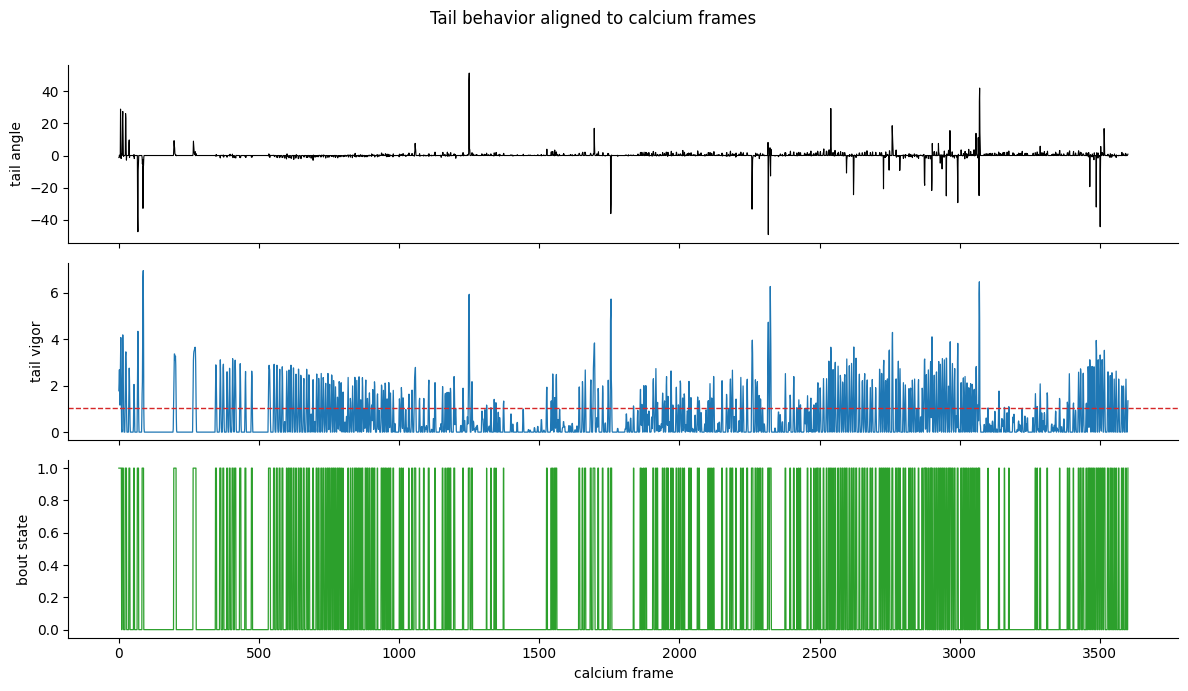

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
frames = np.arange(raw.shape[0])
axes[0].plot(frames, targets.angle, color="black", lw=0.8)
axes[0].set_ylabel("tail angle")
axes[1].plot(frames, targets.vigor, color="tab:blue", lw=0.9)
axes[1].axhline(targets.bout_threshold, color="tab:red", ls="--", lw=1)
axes[1].set_ylabel("tail vigor")
axes[2].plot(frames, targets.bout_state, color="tab:green", lw=0.9)
axes[2].set_ylabel("bout state")
axes[2].set_xlabel("calcium frame")
fig.suptitle("Tail behavior aligned to calcium frames")
fig.tight_layout(rect=(0, 0, 1, 0.97))
target_plot_path = CHAINED_FIGURE_DIR / f"tail_behavior_alignment_{dataset.data_name}.png"
fig.savefig(target_plot_path, dpi=PLOT_DPI, bbox_inches="tight")
print(f"Saved target alignment plot: {target_plot_path.relative_to(PROJECT_ROOT)}")


## Chained Supervised Behavior Decoding

This section decodes behavior from the raw traces and from the cleaned traces produced by `cluster_clean_reconstruct.ipynb`. These outputs are stage-dependent and descriptive.

In [7]:
trace_preservation = summarize_trace_preservation(variants, reference_name="raw")
trace_preservation_path = CHAINED_OUTPUT_DIR / "full_recording_trace_preservation.csv"
trace_preservation.to_csv(trace_preservation_path, index=False)
print(f"Saved trace preservation metrics: {trace_preservation_path.relative_to(PROJECT_ROOT)}")
trace_preservation


Saved trace preservation metrics: outputs/behavior_decoding/v2a-RSNs/220119_F2_run11/full_recording_trace_preservation.csv


,variant,path,reference,n_frames,n_neurons,global_pearson,neuron_pearson_mean,neuron_pearson_median,neuron_pearson_q25,neuron_pearson_q75,rmse_mean,nrmse_mean,mean_abs_delta,variance_ratio_median,variance_ratio_q25,variance_ratio_q75
0,raw,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220119_F2_run11/220119_F2_F2_run11_cells_fluo...,raw,3601,100,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
1,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/incremental...,raw,3601,100,0.978376,0.503891,0.509424,0.379281,0.616703,1.055190,0.837120,0.835258,0.259513,0.143858,0.380323
2,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/incremental...,raw,3601,100,0.981621,0.587641,0.587462,0.455449,0.718138,0.976418,0.780248,0.776497,0.345112,0.207435,0.515723
3,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/incremental...,raw,3601,100,0.985222,0.693988,0.694274,0.599937,0.772680,0.874145,0.697939,0.695633,0.482019,0.359929,0.597035
4,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/incremental...,raw,3601,100,0.989430,0.793393,0.788865,0.737742,0.851407,0.738779,0.591251,0.588476,0.622311,0.544263,0.724893
5,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/incremental...,raw,3601,100,0.994160,0.891584,0.895425,0.862419,0.925780,0.548987,0.440388,0.436461,0.801794,0.743767,0.857069
6,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/fastica/incremental...,raw,3601,100,0.996768,0.941449,0.943365,0.924268,0.962529,0.406155,0.325143,0.322928,0.889946,0.854271,0.926462
7,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/infomax/incremental...,raw,3601,100,0.983082,0.614206,0.621697,0.527513,0.722097,0.947854,0.763368,0.746744,0.386508,0.278296,0.521429
8,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/infomax/incremental...,raw,3601,100,0.985098,0.647224,0.645251,0.553580,0.757393,0.897319,0.733047,0.710051,0.416355,0.306451,0.573645
9,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/linear/v2a-RSNs/220119_F2_run11/infomax/incremental...,raw,3601,100,0.987829,0.689012,0.704437,0.597669,0.809737,0.815382,0.685352,0.645646,0.496237,0.357220,0.655689


In [8]:
if RUN_CHAINED_BEHAVIOR_DECODING:
    common_kwargs = dict(
        variants=variants,
        lags=DECODER_LAGS,
        target_shift=TARGET_SHIFT,
        n_splits=BEHAVIOR_N_SPLITS,
        gap=BEHAVIOR_GAP,
        ridge_alpha=RIDGE_ALPHA,
        include_transfer=True,
        include_null=True,
        null_block_size=NULL_BLOCK_SIZE,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )
    vigor_result = run_decoding_experiment(
        target=targets.vigor,
        target_name="tail_vigor",
        task="regression",
        **common_kwargs,
    )
    bout_result = run_decoding_experiment(
        target=targets.bout_state,
        target_name="bout_state",
        task="classification",
        **common_kwargs,
    )

    supervised_metrics = pd.concat([vigor_result.metrics, bout_result.metrics], ignore_index=True)
    supervised_summary = pd.concat([vigor_result.summary, bout_result.summary], ignore_index=True)
    supervised_predictions = pd.concat([vigor_result.predictions, bout_result.predictions], ignore_index=True)
else:
    supervised_metrics = pd.DataFrame()
    supervised_summary = pd.DataFrame()
    supervised_predictions = pd.DataFrame()

supervised_summary.head(40)


,target,task,comparison,train_version,test_version,r2_mean,r2_std,pearson_mean,pearson_std,spearman_mean,...,rmse_mean,rmse_std,nrmse_mean,nrmse_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,roc_auc_mean,roc_auc_std
0,tail_vigor,regression,null_within,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,-0.017849,0.016661,0.026268,0.025999,0.047123,...,0.916423,0.035825,1.008858,0.008214,NaN,NaN,NaN,NaN,NaN,NaN
1,tail_vigor,regression,null_within,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,-0.025761,0.019687,0.026099,0.013008,0.028245,...,0.919983,0.036687,1.012761,0.009678,NaN,NaN,NaN,NaN,NaN,NaN
2,tail_vigor,regression,null_within,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,-0.058852,0.024749,-0.010308,0.029091,0.005763,...,0.934710,0.038407,1.028949,0.012006,NaN,NaN,NaN,NaN,NaN,NaN
3,tail_vigor,regression,null_within,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,-0.082544,0.015754,-0.011234,0.016734,0.004697,...,0.945106,0.036756,1.040432,0.007569,NaN,NaN,NaN,NaN,NaN,NaN
4,tail_vigor,regression,null_within,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,-0.131051,0.045616,-0.027152,0.051088,-0.003613,...,0.965733,0.035960,1.063335,0.021488,NaN,NaN,NaN,NaN,NaN,NaN
5,tail_vigor,regression,null_within,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence,-0.169688,0.046711,-0.043534,0.041265,-0.020871,...,0.982048,0.034942,1.081347,0.021696,NaN,NaN,NaN,NaN,NaN,NaN
6,tail_vigor,regression,null_within,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence,-0.015352,0.018467,0.027690,0.046149,0.048668,...,0.915366,0.038221,1.007613,0.009154,NaN,NaN,NaN,NaN,NaN,NaN
7,tail_vigor,regression,null_within,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence,-0.023929,0.027036,0.019247,0.057685,0.043049,...,0.919123,0.037326,1.011824,0.013318,NaN,NaN,NaN,NaN,NaN,NaN
8,tail_vigor,regression,null_within,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence,-0.027332,0.012618,0.005160,0.030209,0.011476,...,0.920931,0.042687,1.013559,0.006234,NaN,NaN,NaN,NaN,NaN,NaN
9,tail_vigor,regression,null_within,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence,-0.031771,0.013523,-0.004029,0.035405,0.003647,...,0.922920,0.042944,1.015744,0.006664,NaN,NaN,NaN,NaN,NaN,NaN


,method,tail_vigor_within_pearson,tail_vigor_within_pearson_preservation_pct,tail_vigor_transfer_pearson,tail_vigor_transfer_pearson_preservation_pct,bout_state_within_balanced_accuracy,bout_state_within_balanced_accuracy_preservation_pct,bout_state_transfer_balanced_accuracy,bout_state_transfer_balanced_accuracy_preservation_pct,behavioral_preservation_index,neuron_pearson_median,nrmse_mean,variance_ratio_median,mean_abs_delta,recommendation_label
0,raw,0.596606,100.000000,0.596606,100.000000,0.735893,100.000000,0.735893,100.000000,100.000000,1.000000,0.000000,1.000000,0.000000,raw reference
1,sobi/keep_top_02/cleaned_sobi_220119_F2_run11_fluorescence,0.611091,102.197971,0.612818,102.460015,0.752961,106.767141,0.746987,104.398761,103.955972,0.719036,0.661608,0.517015,0.645780,best preserved
2,sobi/keep_top_03/cleaned_sobi_220119_F2_run11_fluorescence,0.604822,101.246652,0.606105,101.441357,0.747371,104.550787,0.748906,105.159536,103.099583,0.781102,0.586622,0.610123,0.569259,acceptable
3,infomax/keep_top_05/cleaned_infomax_220119_F2_run11_fluorescence,0.611779,102.302371,0.610934,102.174143,0.744858,103.554702,0.744977,103.601701,102.908229,0.846525,0.505817,0.716605,0.451949,acceptable
4,sobi/keep_top_04/cleaned_sobi_220119_F2_run11_fluorescence,0.597697,100.165560,0.599448,100.431206,0.746012,104.011961,0.750183,105.665697,102.568606,0.853521,0.508509,0.728498,0.492465,acceptable
5,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence,0.605040,101.279698,0.606009,101.426753,0.750103,105.634153,0.740257,101.730472,102.517769,0.707947,0.672757,0.501198,0.631112,acceptable
6,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence,0.591592,99.239258,0.596937,100.050247,0.750177,105.663364,0.744718,103.498944,102.112953,0.645251,0.733047,0.416355,0.710051,acceptable
7,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence,0.593583,99.541360,0.600515,100.593135,0.752427,106.555365,0.740246,101.725895,102.103939,0.704437,0.685352,0.496237,0.645646,acceptable
8,infomax/keep_top_06/cleaned_infomax_220119_F2_run11_fluorescence,0.597355,100.113683,0.599326,100.412782,0.742271,102.528825,0.747191,104.479593,101.883721,0.940365,0.361553,0.884286,0.310367,acceptable
9,sobi/keep_top_05/cleaned_sobi_220119_F2_run11_fluorescence,0.599665,100.464188,0.600089,100.528559,0.741620,102.270617,0.742422,102.588860,101.463056,0.916699,0.396830,0.840337,0.384831,acceptable


,target,task,method,selection_id,clusters_kept,score_metric,score,delta_vs_prev,delta_vs_raw,variant
0,bout_state,classification,fastica,keep_top_01,1.0,balanced_accuracy_mean,0.597082,NaN,-0.138811,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence
1,bout_state,classification,fastica,keep_top_02,2.0,balanced_accuracy_mean,0.620042,0.022961,-0.115851,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence
2,bout_state,classification,fastica,keep_top_03,3.0,balanced_accuracy_mean,0.656866,0.036824,-0.079027,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence
3,bout_state,classification,fastica,keep_top_04,4.0,balanced_accuracy_mean,0.677710,0.020844,-0.058183,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence
4,bout_state,classification,fastica,keep_top_05,5.0,balanced_accuracy_mean,0.703012,0.025302,-0.032881,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence
5,bout_state,classification,fastica,keep_top_06,6.0,balanced_accuracy_mean,0.718101,0.015089,-0.017792,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence
6,bout_state,classification,infomax,keep_top_01,1.0,balanced_accuracy_mean,0.747958,NaN,0.012065,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence
7,bout_state,classification,infomax,keep_top_02,2.0,balanced_accuracy_mean,0.750177,0.002219,0.014284,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence
8,bout_state,classification,infomax,keep_top_03,3.0,balanced_accuracy_mean,0.752427,0.002250,0.016534,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence
9,bout_state,classification,infomax,keep_top_04,4.0,balanced_accuracy_mean,0.750103,-0.002323,0.014210,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence


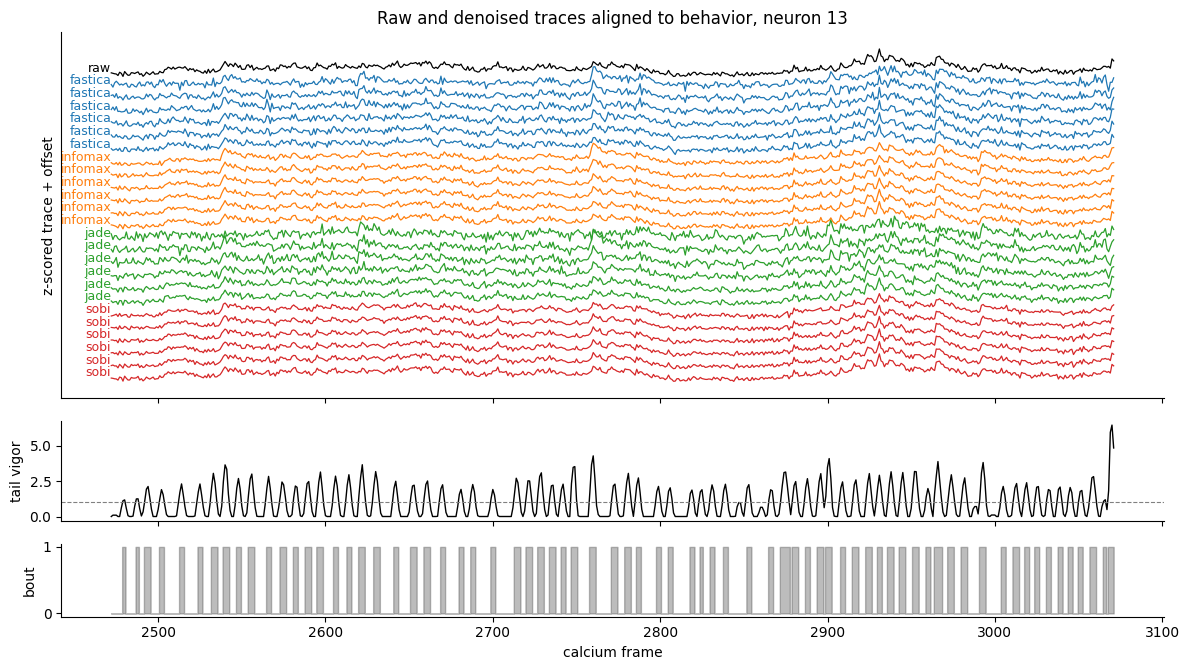

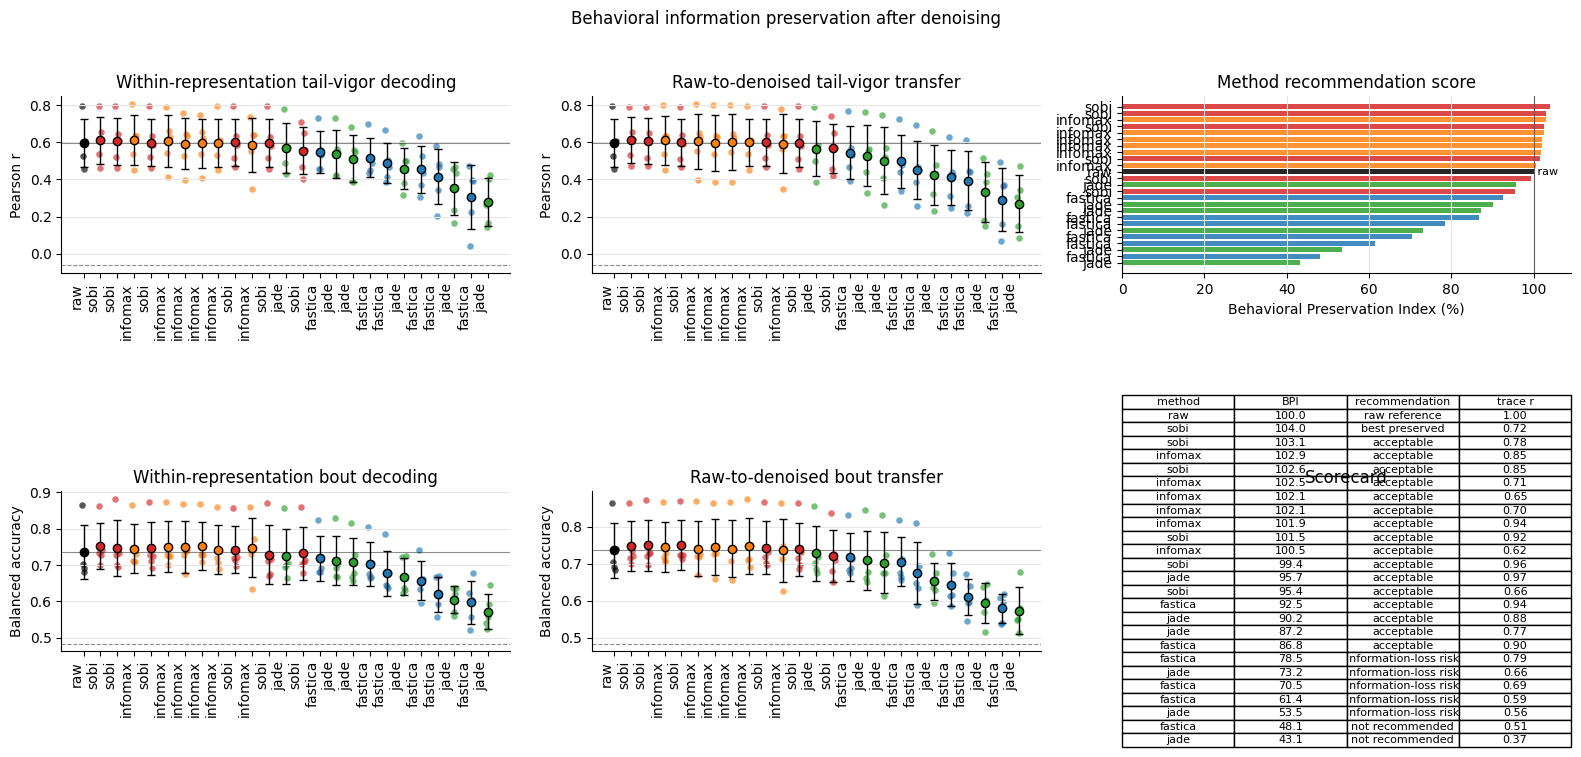

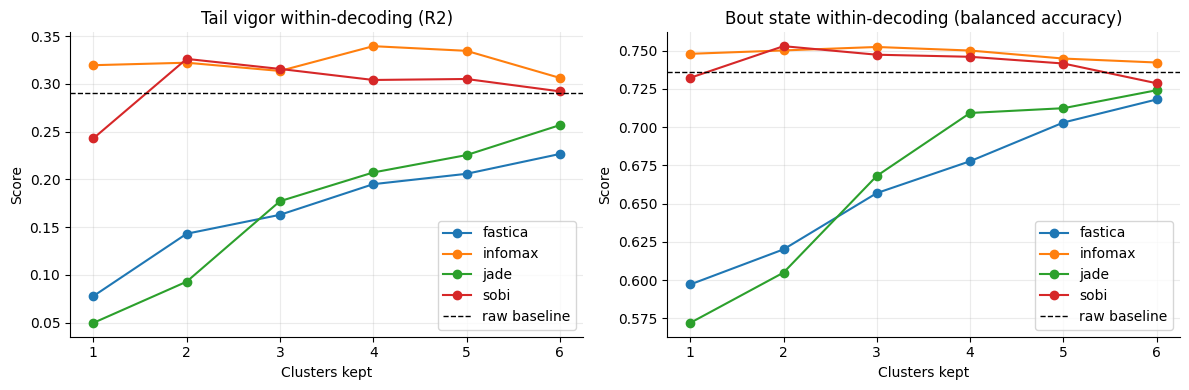

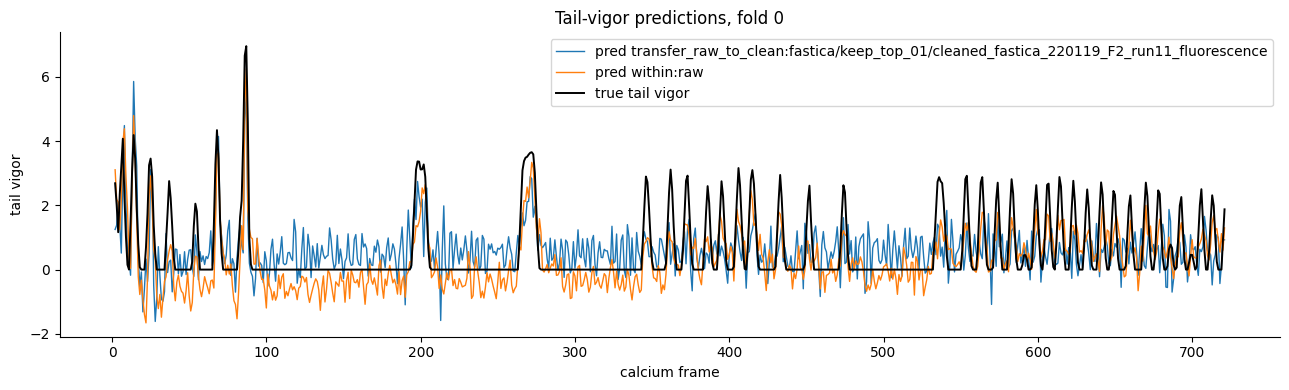

In [9]:
if RUN_CHAINED_BEHAVIOR_DECODING:
    trace_evidence_fig, _ = plot_behavior_trace_evidence(
        variants,
        targets,
        window_size=600,
    )
    preservation_fig, _, behavior_scorecard = plot_behavior_preservation_summary(
        supervised_metrics,
        supervised_summary,
        variants=variants,
    )

    variant_meta = trace_table[["variant", "method", "selection_id", "clusters_kept", "is_incremental"]].copy()
    within_summary = supervised_summary[supervised_summary["comparison"] == "within"].copy().rename(
        columns={"test_version": "variant"}
    )
    within_summary = within_summary.merge(variant_meta, on="variant", how="left")
    within_summary["score"] = np.where(
        within_summary["task"] == "regression",
        within_summary["r2_mean"],
        within_summary["balanced_accuracy_mean"],
    )
    within_summary["score_metric"] = np.where(
        within_summary["task"] == "regression",
        "r2_mean",
        "balanced_accuracy_mean",
    )
    raw_baseline = within_summary[within_summary["variant"] == "raw"][["target", "task", "score"]].rename(
        columns={"score": "raw_score"}
    )

    cluster_progress_table = (
        within_summary[within_summary["is_incremental"]]
        .merge(raw_baseline, on=["target", "task"], how="left")
        .sort_values(["target", "task", "method", "clusters_kept"])
        .copy()
    )
    if not cluster_progress_table.empty:
        cluster_progress_table["delta_vs_prev"] = cluster_progress_table.groupby(
            ["target", "task", "method"]
        )["score"].diff()
        cluster_progress_table["delta_vs_raw"] = cluster_progress_table["score"] - cluster_progress_table["raw_score"]
        cluster_progress_table = cluster_progress_table[
            [
                "target",
                "task",
                "method",
                "selection_id",
                "clusters_kept",
                "score_metric",
                "score",
                "delta_vs_prev",
                "delta_vs_raw",
                "variant",
            ]
        ].reset_index(drop=True)

        progress_plot_targets = [
            ("tail_vigor", "Tail vigor within-decoding (R2)"),
            ("bout_state", "Bout state within-decoding (balanced accuracy)"),
        ]
        cluster_progress_fig, axes = plt.subplots(
            1,
            len(progress_plot_targets),
            figsize=(6 * len(progress_plot_targets), 4),
        )
        axes = np.atleast_1d(axes)
        for ax, (target_name, title) in zip(axes, progress_plot_targets):
            target_rows = cluster_progress_table[cluster_progress_table["target"] == target_name]
            for method_name, group in target_rows.groupby("method"):
                group = group.sort_values("clusters_kept")
                ax.plot(
                    group["clusters_kept"],
                    group["score"],
                    marker="o",
                    lw=1.5,
                    label=method_name,
                )
            task_name = "regression" if target_name == "tail_vigor" else "classification"
            raw_row = raw_baseline[(raw_baseline["target"] == target_name) & (raw_baseline["task"] == task_name)]
            if not raw_row.empty and np.isfinite(raw_row["raw_score"].iloc[0]):
                ax.axhline(
                    raw_row["raw_score"].iloc[0],
                    color="black",
                    linestyle="--",
                    linewidth=1,
                    label="raw baseline",
                )
            if not target_rows.empty:
                ax.set_xticks(sorted(target_rows["clusters_kept"].dropna().astype(int).unique()))
            ax.set_title(title)
            ax.set_xlabel("Clusters kept")
            ax.set_ylabel("Score")
            ax.grid(alpha=0.25)
            ax.legend(loc="best")
        cluster_progress_fig.tight_layout()
    else:
        cluster_progress_fig = None
        print("No incremental keep-top variants detected for supervised behavior progression.")

    prediction_variant_meta = trace_table[
        ["variant", "method", "clusters_kept", "is_incremental"]
    ].copy()
    prediction_variant_meta = prediction_variant_meta[prediction_variant_meta["variant"] != "raw"].copy()
    prediction_variant_meta["is_incremental_sort"] = prediction_variant_meta["is_incremental"].fillna(False).astype(bool)
    prediction_transfer_meta = (
        prediction_variant_meta.sort_values(
            ["method", "is_incremental_sort", "clusters_kept"],
            ascending=[True, True, False],
            na_position="last",
        )
        .groupby("method", as_index=False)
        .head(1)
    )
    prediction_transfer_versions = prediction_transfer_meta["variant"].tolist()
    method_label_map = {
        "fastica": "fastICA",
        "infomax": "Infomax",
        "jade": "JADE",
        "sobi": "SOBI",
    }
    prediction_label_by_version = {
        row.variant: f"pred transfer_raw_to_clean:{method_label_map.get(row.method, row.method)}"
        for row in prediction_transfer_meta.itertuples()
    }
    prediction_trace_figs = []
    prediction_folds = sorted(
        supervised_predictions.loc[
            supervised_predictions["target"] == "tail_vigor", "fold"
        ].dropna().astype(int).unique()
    )
    for fold in prediction_folds:
        prediction_plot_df = supervised_predictions.query(
            "target == 'tail_vigor' and fold == @fold and "
            "((comparison == 'within' and test_version == 'raw') or "
            "(comparison == 'transfer_raw_to_clean' and test_version in @prediction_transfer_versions))"
        ).copy()
        if prediction_plot_df.empty:
            continue
        prediction_trace_fig, ax = plt.subplots(figsize=(13, 4))
        for label, group in prediction_plot_df.groupby(["comparison", "test_version"]):
            group = group.sort_values("time_index")
            plot_label = prediction_label_by_version.get(label[1], f"pred {label[0]}:{label[1]}")
            ax.plot(group["time_index"], group["y_pred"], lw=1, label=plot_label)
        truth = prediction_plot_df.drop_duplicates("time_index").sort_values("time_index")
        ax.plot(truth["time_index"], truth["y_true"], color="black", lw=1.4, label="true tail vigor")
        ax.set_title(f"Tail-vigor predictions, fold {fold}")
        ax.set_xlabel("calcium frame")
        ax.set_ylabel("tail vigor")
        window_start = float(truth["time_index"].min()) if not truth.empty else 0.0
        ax.set_xlim(window_start, window_start + 400)
        ax.legend(loc="best")
        prediction_trace_fig.tight_layout()
        prediction_trace_figs.append((fold, prediction_trace_fig))

    supervised_metrics.to_csv(CHAINED_OUTPUT_DIR / "full_recording_behavior_fold_metrics.csv", index=False)
    supervised_summary.to_csv(CHAINED_OUTPUT_DIR / "full_recording_behavior_summary.csv", index=False)
    supervised_predictions.to_csv(CHAINED_OUTPUT_DIR / "full_recording_behavior_predictions.csv", index=False)
    behavior_scorecard.to_csv(CHAINED_OUTPUT_DIR / "full_recording_behavior_scorecard.csv", index=False)
    behavior_scorecard.to_csv(CHAINED_OUTPUT_DIR / "behavior_preservation_scorecard.csv", index=False)
    if "cluster_progress_table" in globals() and isinstance(cluster_progress_table, pd.DataFrame):
        cluster_progress_table.to_csv(CHAINED_OUTPUT_DIR / "cluster_progression_summary.csv", index=False)
    trace_evidence_fig.savefig(
        CHAINED_FIGURE_DIR / f"full_recording_trace_behavior_evidence_{dataset.data_name}.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    trace_evidence_fig.savefig(
        CHAINED_FIGURE_DIR / "paper_trace_behavior_evidence.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    preservation_fig.savefig(
        CHAINED_FIGURE_DIR / f"full_recording_behavior_preservation_summary_{dataset.data_name}.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    preservation_fig.savefig(
        CHAINED_FIGURE_DIR / "paper_behavior_preservation_summary.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    if cluster_progress_fig is not None:
        cluster_progress_fig.savefig(
            CHAINED_FIGURE_DIR / "cluster_progression_summary.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
        cluster_progress_fig.savefig(
            CHAINED_FIGURE_DIR / "paper_cluster_progression_summary.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
    for fold, prediction_trace_fig in prediction_trace_figs:
        prediction_trace_fig.savefig(
            CHAINED_FIGURE_DIR / f"tail_vigor_prediction_trace_fold_{fold}.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
        if fold == prediction_folds[0]:
            prediction_trace_fig.savefig(
                CHAINED_FIGURE_DIR / "tail_vigor_prediction_trace.png",
                dpi=PLOT_DPI,
                bbox_inches="tight",
            )
    display(behavior_scorecard)
    if "cluster_progress_table" in globals():
        display(cluster_progress_table)


## Chained Causal-State Behavior Decoding

This uses the same raw and cluster-cleaned trace variants loaded above.

In [10]:
if RUN_CHAINED_BEHAVIOR_DECODING:
    causal_config = CausalStateConfig(
        window=CAUSAL_WINDOW,
        target_shifts=CAUSAL_TARGET_SHIFTS,
        latent_dim=CAUSAL_LATENT_DIM,
        n_splits=CAUSAL_N_SPLITS,
        gap=CAUSAL_GAP,
        ridge_alpha=CAUSAL_RIDGE_ALPHA,
        bout_quantile=BOUT_QUANTILE,
        random_state=RANDOM_STATE,
    )
    causal_result = fit_causal_state_model(
        variants=variants,
        targets=targets,
        config=causal_config,
    )
    causal_summary = (
        causal_result.fold_metrics.groupby(["variant", "target_shift"], dropna=False)
        .agg(
            dynamic_mse_normalized_mean=("dynamic_mse_normalized", "mean"),
            dynamic_improvement_vs_persistence_mean=("dynamic_improvement_vs_persistence", "mean"),
            angle_pearson_mean=("angle_pearson", "mean"),
            vigor_pearson_mean=("vigor_pearson", "mean"),
            bout_balanced_accuracy_mean=("bout_balanced_accuracy", "mean"),
        )
        .reset_index()
    )
else:
    causal_result = None
    causal_summary = pd.DataFrame()

causal_summary.head(40)


,variant,target_shift,dynamic_mse_normalized_mean,dynamic_improvement_vs_persistence_mean,angle_pearson_mean,vigor_pearson_mean,bout_balanced_accuracy_mean
0,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,0,0.022775,0.080117,0.078311,0.122309,0.518453
1,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,0,0.014800,0.052167,0.100479,0.202005,0.558761
2,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,0,0.013976,0.077375,0.087814,0.216852,0.552751
3,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,0,0.011716,-0.013374,0.101287,0.213927,0.570449
4,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,0,0.010656,-0.001983,0.103081,0.214392,0.550488
5,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence,0,0.009228,0.007941,0.096470,0.235108,0.541602
6,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence,0,0.007884,0.017921,0.105675,0.255846,0.588341
7,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence,0,0.008342,0.011873,0.086534,0.250164,0.580077
8,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence,0,0.008359,0.012234,0.091010,0.257644,0.584679
9,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence,0,0.008339,0.011125,0.088894,0.260055,0.579852


Saved causal diagnostics plot: outputs/behavior_decoding/v2a-RSNs/220119_F2_run11/figures/full_recording_causal_diagnostics_220119_F2_run11_fluorescence.png


,variant,target_shift,corr_to_angle_next,corr_to_vigor_next,corr_to_bout_next,residual_vigor_corr,residual_bout_corr,variant_label
0,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence,0,-0.000605,0.006238,0.002403,0.243594,0.135619,FastICA-k1
1,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence,0,-0.001726,0.005030,-0.006958,0.304786,0.175121,FastICA-k2
2,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence,0,0.010923,0.039253,0.027700,0.280301,0.157157,FastICA-k3
3,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence,0,0.027623,0.034743,0.022102,0.279219,0.165158,FastICA-k4
4,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence,0,0.019445,0.083337,0.073005,0.275300,0.161975,FastICA-k5
5,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence,0,0.012735,0.028331,0.018467,0.283353,0.170121,FastICA-k6
6,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence,0,0.004399,-0.006872,-0.006358,0.289943,0.175489,Infomax-k1
7,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence,0,0.014043,0.024627,0.012741,0.295572,0.183298,Infomax-k2
8,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence,0,0.019782,0.026752,0.013857,0.288227,0.171046,Infomax-k3
9,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence,0,0.005940,0.035236,0.024769,0.290745,0.174190,Infomax-k4


,metric,method,selection_id,clusters_kept,target_shift,score,delta_vs_prev,delta_vs_raw,variant
0,bout_balanced_accuracy,fastica,keep_top_01,1.0,0,0.518453,NaN,-0.052426,fastica/keep_top_01/cleaned_fastica_220119_F2_run11_fluorescence
1,bout_balanced_accuracy,fastica,keep_top_02,2.0,0,0.558761,0.040308,-0.012118,fastica/keep_top_02/cleaned_fastica_220119_F2_run11_fluorescence
2,bout_balanced_accuracy,fastica,keep_top_03,3.0,0,0.552751,-0.006010,-0.018127,fastica/keep_top_03/cleaned_fastica_220119_F2_run11_fluorescence
3,bout_balanced_accuracy,fastica,keep_top_04,4.0,0,0.570449,0.017698,-0.000429,fastica/keep_top_04/cleaned_fastica_220119_F2_run11_fluorescence
4,bout_balanced_accuracy,fastica,keep_top_05,5.0,0,0.550488,-0.019962,-0.020391,fastica/keep_top_05/cleaned_fastica_220119_F2_run11_fluorescence
5,bout_balanced_accuracy,fastica,keep_top_06,6.0,0,0.541602,-0.008886,-0.029277,fastica/keep_top_06/cleaned_fastica_220119_F2_run11_fluorescence
6,bout_balanced_accuracy,infomax,keep_top_01,1.0,0,0.588341,NaN,0.017463,infomax/keep_top_01/cleaned_infomax_220119_F2_run11_fluorescence
7,bout_balanced_accuracy,infomax,keep_top_02,2.0,0,0.580077,-0.008264,0.009199,infomax/keep_top_02/cleaned_infomax_220119_F2_run11_fluorescence
8,bout_balanced_accuracy,infomax,keep_top_03,3.0,0,0.584679,0.004601,0.013800,infomax/keep_top_03/cleaned_infomax_220119_F2_run11_fluorescence
9,bout_balanced_accuracy,infomax,keep_top_04,4.0,0,0.579852,-0.004827,0.008973,infomax/keep_top_04/cleaned_infomax_220119_F2_run11_fluorescence


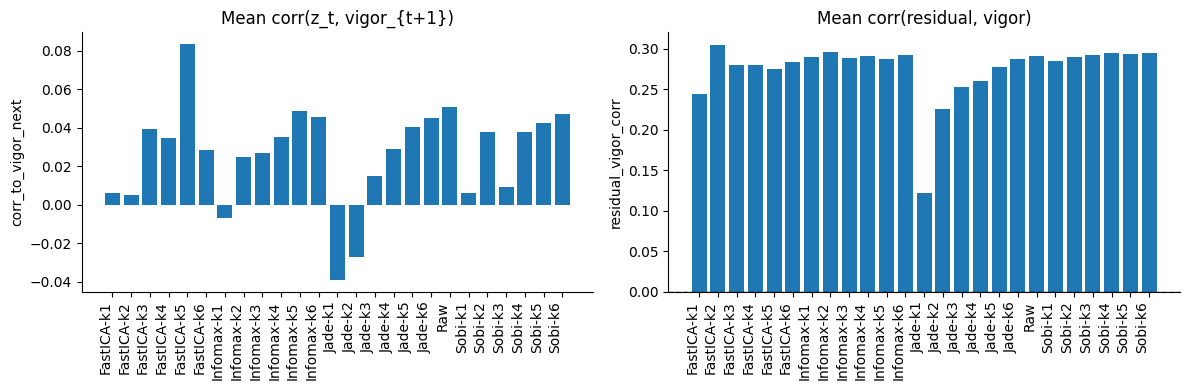

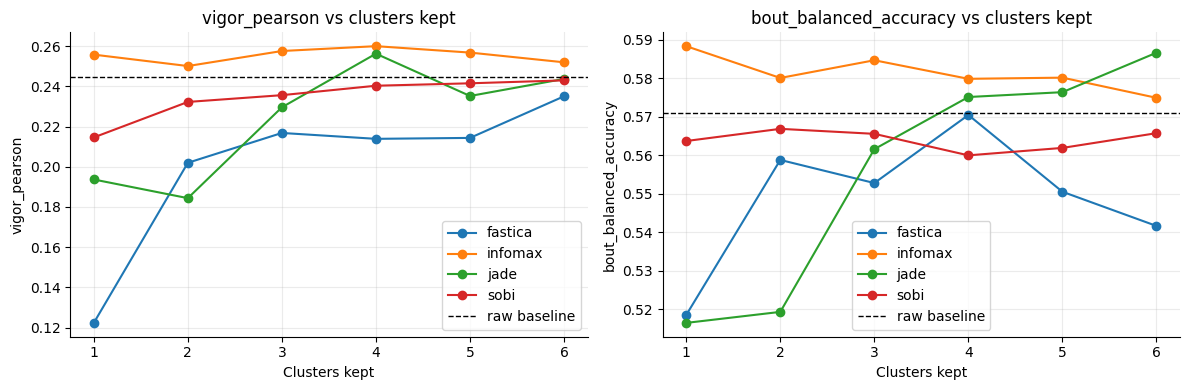

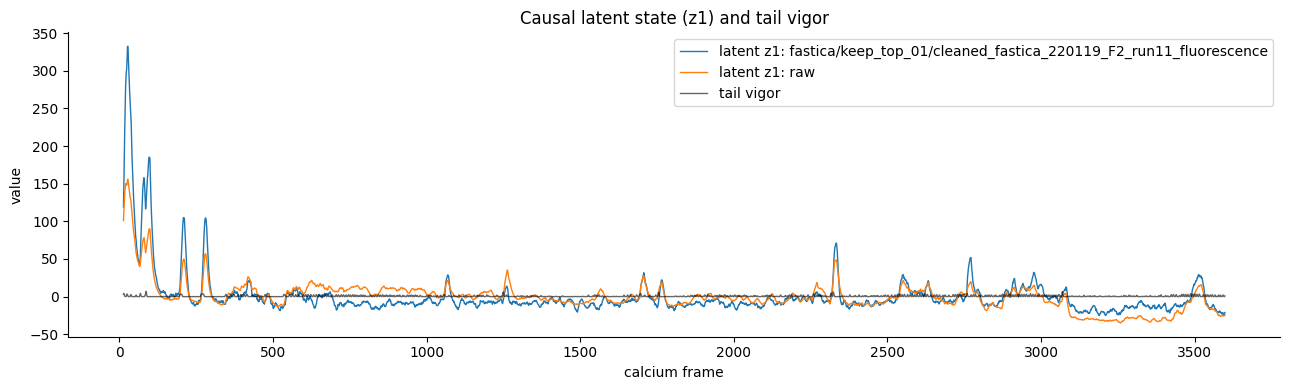

In [11]:
if RUN_CHAINED_BEHAVIOR_DECODING and causal_result is not None:
    causal_result.fold_metrics.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_fold_metrics.csv", index=False)
    causal_summary.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_summary.csv", index=False)
    causal_result.embeddings.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_embeddings.csv", index=False)
    causal_result.graph_metrics.to_csv(
        CHAINED_OUTPUT_DIR / "full_recording_causal_latent_behavior_correlations.csv",
        index=False,
    )
    causal_result.residual_tests.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_residual_tests.csv", index=False)

    graph_summary = causal_result.graph_metrics.groupby(["variant", "target_shift"], as_index=False)[
        ["corr_to_angle_next", "corr_to_vigor_next", "corr_to_bout_next"]
    ].mean()
    resid_summary = causal_result.residual_tests.groupby(["variant", "target_shift"], as_index=False)[
        ["residual_vigor_corr", "residual_bout_corr"]
    ].mean()
    causal_diag = graph_summary.merge(resid_summary, on=["variant", "target_shift"], how="left")

    def _short_variant_label(name: str) -> str:
        if name == "raw":
            return "Raw"
        parts = name.split("/")
        method = parts[0] if parts else name
        method_label = {
            "fastica": "FastICA",
            "infomax": "Infomax",
        }.get(method, method.replace("_", " ").title().replace(" ", ""))
        selection_id = _selection_id_from_variant(name)
        clusters_kept = _clusters_kept_from_selection(selection_id)
        if pd.notna(clusters_kept):
            return f"{method_label}-k{int(clusters_kept)}"
        return method_label

    causal_diag["variant_label"] = causal_diag["variant"].map(_short_variant_label)
    causal_diag.to_csv(CHAINED_OUTPUT_DIR / "full_recording_causal_diagnostics_summary.csv", index=False)

    causal_diag_fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(causal_diag))
    labels = causal_diag["variant_label"].astype(str).tolist()
    bar_colors = ["black" if variant == "raw" else "tab:blue" for variant in causal_diag["variant"]]
    axes[0].bar(x, causal_diag["corr_to_vigor_next"].to_numpy(dtype=float), color=bar_colors)
    raw_rows = causal_diag[causal_diag["variant"] == "raw"]
    if not raw_rows.empty:
        raw_corr = float(raw_rows.iloc[0]["corr_to_vigor_next"])
        if np.isfinite(raw_corr):
            axes[0].axhline(raw_corr, color="black", linewidth=0.5)
    axes[0].set_title("Mean corr(z_t, vigor_{t+1})")
    axes[0].set_ylabel("corr_to_vigor_next")
    axes[1].bar(x, causal_diag["residual_vigor_corr"].to_numpy(dtype=float), color=bar_colors)
    axes[1].axhline(0.0, linestyle="--", linewidth=1, color="black")
    if not raw_rows.empty:
        raw_resid = float(raw_rows.iloc[0]["residual_vigor_corr"])
        if np.isfinite(raw_resid):
            axes[1].axhline(raw_resid, color="black", linewidth=0.5)
    axes[1].set_title("Mean corr(residual, vigor)")
    axes[1].set_ylabel("residual_vigor_corr")
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=90, ha="right")
        ax.set_xlabel("")
    causal_diag_fig.tight_layout()
    causal_diag_plot_path = CHAINED_FIGURE_DIR / f"full_recording_causal_diagnostics_{dataset.data_name}.png"
    causal_diag_fig.savefig(causal_diag_plot_path, dpi=PLOT_DPI, bbox_inches="tight")
    causal_diag_fig.savefig(CHAINED_FIGURE_DIR / "paper_causal_diagnostics_summary.png", dpi=PLOT_DPI, bbox_inches="tight")
    print(f"Saved causal diagnostics plot: {causal_diag_plot_path.relative_to(PROJECT_ROOT)}")

    variant_meta = trace_table[["variant", "method", "selection_id", "clusters_kept", "is_incremental"]].copy()
    causal_summary_with_meta = causal_summary.merge(variant_meta, on="variant", how="left")
    causal_metric_specs = [
        ("vigor_pearson_mean", "vigor_pearson"),
        ("bout_balanced_accuracy_mean", "bout_balanced_accuracy"),
    ]
    progress_frames = []
    for metric_column, metric_name in causal_metric_specs:
        metric_df = causal_summary_with_meta[
            [
                "variant",
                "target_shift",
                "method",
                "selection_id",
                "clusters_kept",
                "is_incremental",
                metric_column,
            ]
        ].copy()
        metric_df = metric_df.rename(columns={metric_column: "score"})
        metric_df["metric"] = metric_name
        raw_scores = metric_df[metric_df["variant"] == "raw"][["target_shift", "score"]].rename(
            columns={"score": "raw_score"}
        )
        metric_df = metric_df[metric_df["is_incremental"]].merge(raw_scores, on="target_shift", how="left")
        progress_frames.append(metric_df)

    causal_cluster_progress = pd.concat(progress_frames, ignore_index=True) if progress_frames else pd.DataFrame()
    if not causal_cluster_progress.empty:
        causal_cluster_progress = causal_cluster_progress.sort_values(
            ["metric", "method", "target_shift", "clusters_kept"]
        )
        causal_cluster_progress["delta_vs_prev"] = causal_cluster_progress.groupby(
            ["metric", "method", "target_shift"]
        )["score"].diff()
        causal_cluster_progress["delta_vs_raw"] = causal_cluster_progress["score"] - causal_cluster_progress["raw_score"]
        causal_cluster_progress = causal_cluster_progress[
            [
                "metric",
                "method",
                "selection_id",
                "clusters_kept",
                "target_shift",
                "score",
                "delta_vs_prev",
                "delta_vs_raw",
                "variant",
            ]
        ].reset_index(drop=True)

        causal_cluster_progress_fig, axes = plt.subplots(
            1,
            len(causal_metric_specs),
            figsize=(6 * len(causal_metric_specs), 4),
        )
        axes = np.atleast_1d(axes)
        baseline_shift = CAUSAL_TARGET_SHIFTS[0] if CAUSAL_TARGET_SHIFTS else 0
        for ax, (metric_column, metric_name) in zip(axes, causal_metric_specs):
            metric_rows = causal_cluster_progress[causal_cluster_progress["metric"] == metric_name]
            for method_name, group in metric_rows.groupby("method"):
                group = group.sort_values("clusters_kept")
                ax.plot(
                    group["clusters_kept"],
                    group["score"],
                    marker="o",
                    lw=1.5,
                    label=method_name,
                )
            baseline_rows = causal_summary_with_meta[
                (causal_summary_with_meta["variant"] == "raw")
                & (causal_summary_with_meta["target_shift"] == baseline_shift)
            ]
            if not baseline_rows.empty:
                baseline_value = baseline_rows.iloc[0][metric_column]
                if np.isfinite(baseline_value):
                    ax.axhline(
                        baseline_value,
                        color="black",
                        linestyle="--",
                        linewidth=1,
                        label="raw baseline",
                    )
            if not metric_rows.empty:
                ax.set_xticks(sorted(metric_rows["clusters_kept"].dropna().astype(int).unique()))
            ax.set_title(f"{metric_name} vs clusters kept")
            ax.set_xlabel("Clusters kept")
            ax.set_ylabel(metric_name)
            ax.grid(alpha=0.25)
            ax.legend(loc="best")
        causal_cluster_progress_fig.tight_layout()
        causal_cluster_progress.to_csv(CHAINED_OUTPUT_DIR / "causal_cluster_progression_summary.csv", index=False)
        causal_cluster_progress_fig.savefig(
            CHAINED_FIGURE_DIR / "causal_cluster_progression_summary.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
        causal_cluster_progress_fig.savefig(
            CHAINED_FIGURE_DIR / "paper_causal_cluster_progression_summary.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )
    else:
        causal_cluster_progress_fig = None
        print("No incremental keep-top variants detected for causal cluster progression.")

    embeddings = causal_result.embeddings.copy()
    causal_latent_meta = variant_meta[variant_meta["variant"] != "raw"].copy()
    causal_latent_meta["is_incremental_sort"] = causal_latent_meta["is_incremental"].fillna(False).astype(bool)
    causal_latent_meta = (
        causal_latent_meta.sort_values(
            ["method", "is_incremental_sort", "clusters_kept"],
            ascending=[True, True, False],
            na_position="last",
        )
        .groupby("method", as_index=False)
        .head(1)
    )
    causal_latent_versions = ["raw", *causal_latent_meta["variant"].tolist()]
    method_label_map = {
        "fastica": "fastICA",
        "infomax": "Infomax",
        "jade": "JADE",
        "sobi": "SOBI",
    }
    causal_latent_label_by_version = {
        "raw": "latent z1:raw",
        **{
            row.variant: f"latent z1:{method_label_map.get(row.method, row.method)}"
            for row in causal_latent_meta.itertuples()
        },
    }
    latent_plot_df = embeddings.query("variant in @causal_latent_versions").sort_values("time_index")
    if latent_plot_df.empty:
        causal_latent_fig = None
    else:
        causal_latent_fig, ax = plt.subplots(figsize=(13, 4))
        for name, group in latent_plot_df.groupby("variant"):
            ax.plot(group["time_index"], group["z1"], lw=1, label=causal_latent_label_by_version.get(name, f"latent z1:{name}"))
        truth = latent_plot_df.drop_duplicates("time_index").sort_values("time_index")
        ax.plot(truth["time_index"], truth["vigor"], color="black", lw=1.0, alpha=0.6, label="tail vigor")
        ax.set_title("Causal latent state (z1) and tail vigor")
        ax.set_xlabel("calcium frame")
        ax.set_ylabel("value")
        ax.legend(loc="best")
        causal_latent_fig.tight_layout()
        causal_latent_fig.savefig(
            CHAINED_FIGURE_DIR / "causal_latent_trace.png",
            dpi=PLOT_DPI,
            bbox_inches="tight",
        )

    display(causal_diag)
    if "causal_cluster_progress" in globals():
        display(causal_cluster_progress)


## Strict Fold-Local Evaluation

This section is optional in the notebook but should be used for primary paper claims. It does not reuse full-recording decompositions or cleaned traces; it refits preprocessing inside each training fold to prevent leakage.

In [12]:
strict_config_path = PROJECT_ROOT / "configs" / STRICT_CONFIG_NAME
strict_config = load_evaluation_config(strict_config_path, sample_rate_hz=float(dataset.sample_rate_hz))
print(f"Strict config: {strict_config_path.relative_to(PROJECT_ROOT)}")
print(f"Strict output directory: {STRICT_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")


Strict config: configs/evaluation.example.json
Strict output directory: outputs/evaluation/v2a-RSNs/220119_F2_run11


In [13]:
if RUN_STRICT_EVALUATION:
    strict_paths = run_dataset_evaluation(
        DATASET_KEY,
        project_root=PROJECT_ROOT,
        config_path=strict_config_path,
        output_root=STRICT_OUTPUT_ROOT,
        output_data_name_override=OUTPUT_DATA_NAME,
    )
else:
    strict_paths = {
        "trace_metrics": STRICT_OUTPUT_DIR / "strict_trace_preservation_metrics.csv",
        "behavior_metrics": STRICT_OUTPUT_DIR / "strict_behavior_fold_metrics.csv",
        "behavior_predictions": STRICT_OUTPUT_DIR / "strict_behavior_predictions.csv",
        "behavior_uncertainty": STRICT_OUTPUT_DIR / "strict_behavior_block_uncertainty.csv",
        "causal_metrics": STRICT_OUTPUT_DIR / "strict_causal_fold_metrics.csv",
        "causal_embeddings": STRICT_OUTPUT_DIR / "strict_causal_oof_embeddings.csv",
        "causal_latent_correlations": STRICT_OUTPUT_DIR / "strict_causal_oof_latent_behavior_correlations.csv",
        "leakage_audit": STRICT_OUTPUT_DIR / "leakage_audit.csv",
        "component_selections": STRICT_OUTPUT_DIR / "component_selections.csv",
        "cluster_stability": STRICT_OUTPUT_DIR / "cluster_stability.csv",
        "cluster_stability_assignments": STRICT_OUTPUT_DIR / "cluster_stability_assignments.csv",
        "variant_metadata": STRICT_OUTPUT_DIR / "variant_metadata.csv",
        "temporal_diagnostics": STRICT_OUTPUT_DIR / "temporal_dependence_diagnostics.csv",
        "bpi_component_scores": STRICT_OUTPUT_DIR / "bpi_component_scores.csv",
        "bpi_ablation": STRICT_OUTPUT_DIR / "bpi_ablation.csv",
        "run_manifest": STRICT_OUTPUT_DIR / "run_manifest.json",
    }

pd.DataFrame(
    {
        "artifact": strict_paths.keys(),
        "path": strict_paths.values(),
        "exists": [path.exists() for path in strict_paths.values()],
    }
)


KeyboardInterrupt: 

In [ ]:
def read_metric_table(path):
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


strict_tables = {
    name: read_metric_table(path)
    for name, path in strict_paths.items()
    if path.suffix == ".csv" and path.exists()
}
strict_manifest = (
    json.loads(strict_paths["run_manifest"].read_text(encoding="utf-8"))
    if strict_paths["run_manifest"].exists()
    else {}
)

artifact_overview = pd.DataFrame(
    [
        {"artifact": name, "rows": len(table), "columns": len(table.columns)}
        for name, table in strict_tables.items()
    ]
).sort_values("artifact")
artifact_overview


In [ ]:
if strict_tables:
    trace_summary = (
        strict_tables["trace_metrics"]
        .groupby(["family", "variant"], dropna=False)[
            [
                "global_pearson",
                "neuron_pearson_median",
                "nrmse_mean",
                "retained_energy_fraction",
                "spectral_power_retention",
                "low_frequency_power_fraction",
            ]
        ]
        .mean()
        .reset_index()
        .sort_values("nrmse_mean")
    )
    behavior_summary = (
        strict_tables["behavior_metrics"]
        .query("comparison in ['within', 'transfer_raw_to_clean']")
        .groupby(["target", "comparison", "test_version"], dropna=False)[
            ["pearson", "nrmse", "balanced_accuracy", "roc_auc"]
        ]
        .mean()
        .reset_index()
    )
    causal_summary_strict = (
        strict_tables["causal_metrics"]
        .groupby(["transition_model", "variant"], dropna=False)[
            [
                "dynamic_mse_normalized",
                "dynamic_improvement_vs_persistence",
                "angle_pearson",
                "vigor_pearson",
                "bout_balanced_accuracy",
            ]
        ]
        .mean()
        .reset_index()
        .sort_values("dynamic_mse_normalized")
    )
    display(trace_summary.head(40))
    display(behavior_summary.head(60))
    display(causal_summary_strict.head(50))


In [ ]:
if strict_tables and strict_manifest:
    print(f"All leakage checks passed: {strict_tables['leakage_audit']['leakage_free'].all()}")
    print(f"All BSS fits converged: {strict_manifest['all_bss_fits_converged']}")
    print(f"All causal fits converged: {strict_manifest['all_causal_fits_converged']}")
    print(f"Strict manifest: {strict_paths['run_manifest'].relative_to(PROJECT_ROOT)}")
    print(f"Chained behavior outputs: {CHAINED_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

    display(strict_tables["behavior_uncertainty"].head(30))
    display(strict_tables["bpi_ablation"].head(30))
    display(strict_tables["temporal_diagnostics"].head(30))
    display(strict_tables["cluster_stability"].head(30))
